```
Runnable（可执行基类）
├── 顺序执行
│   ├── RunnableSequence   顺序链
│   ├── | 管道             串联操作符（最常用）
│   └── pipe()             管道方法
├── 函数包装
│   ├── RunnableLambda     把函数变成链
│   ├── RunnableGenerator  生成器包装
│   └── bind()             预绑定参数
├── 透传映射
│   ├── RunnablePassthrough  透传（不改输入）
│   ├── assign()             透传并加键
│   └── RunnablePick         从 dict 取值
└── 并行分支
    ├── RunnableParallel     并行执行多分支
    ├── RunnableMap          键值映射
    └── RunnableBranch       条件分支
```

## 1. invoke, stream, batch

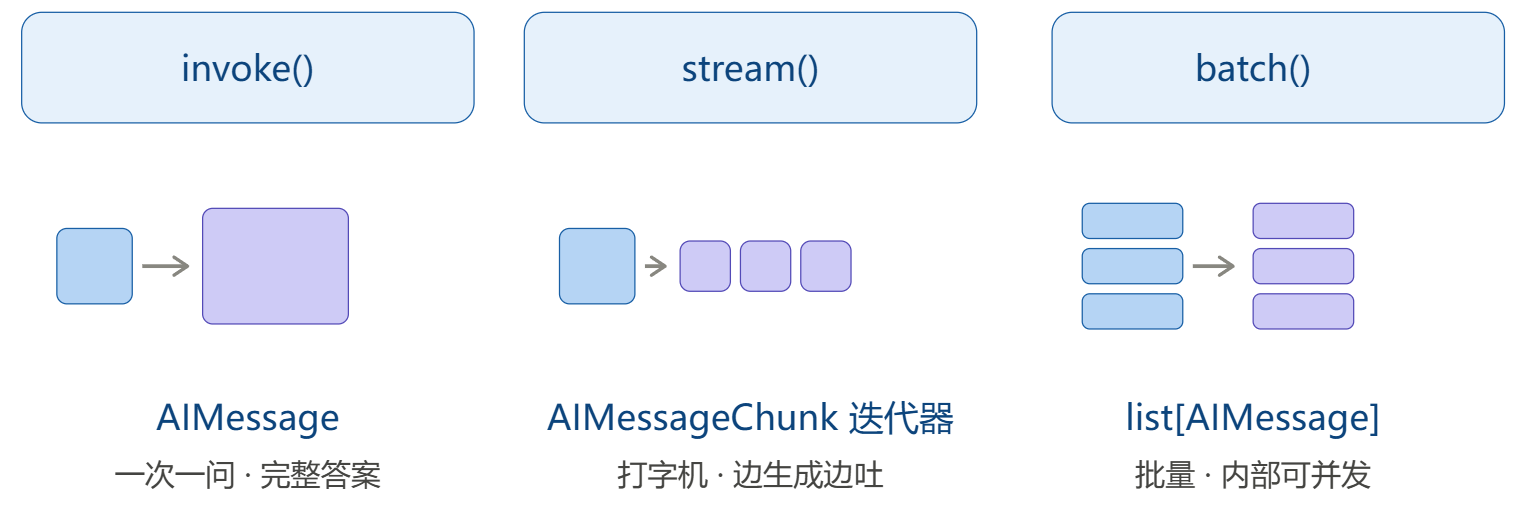

In [22]:
from operator import itemgetter

from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import  StrOutputParser

model = init_chat_model(model="deepseek-flash")
prompt = ChatPromptTemplate.from_messages([
    ("system", "你是翻译助手"),
    ("human", "用五种语言翻译以下文字：{text}")
])
output_parser = StrOutputParser()
chain = prompt | model | output_parser

### 1.1 invoke

In [23]:
# invoke
res = chain.invoke({"text": "你好吗，今天天气真好啊！"})
print(type(res))
print(res)

<class 'langchain_core.messages.base.TextAccessor'>
英语：How are you? The weather is really nice today!  
日语：お元気ですか？今日は本当にいい天気ですね！  
韩语：잘 지내세요? 오늘 날씨가 정말 좋네요!  
法语：Comment allez-vous ? Il fait vraiment beau aujourd'hui !  
西班牙语：¿Cómo estás? ¡Qué buen tiempo hace hoy!


### 1.2 stream

In [25]:
# stream:
res = chain.stream({"text": "你好吗，今天天气真好啊！"})
print(type(res))
for chunk in res:
    print(chunk, end="|", flush=True)  #flush=True 刷新缓冲区

<class 'generator'>
|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||以下|以|英|、|日|、|韩|、|法|、|西|五种

### 1.3 batch

In [27]:
# batch
# 注意事项
# API供应商可能有批量请求限制（如每分钟请求数）
# 输入列表中的所有字典必须有相同的键结构
# 批量处理不适合有状态的操作（如带记忆的对话链）
texts = ["人工智能", "区块链"]
inputs = [{"text": text} for text in texts]

batch_result = chain.batch(inputs)
print(type(res))
for i, res in enumerate(batch_result):
    print(f"{texts[i]}: {res}")

<class 'langchain_core.messages.base.TextAccessor'>
人工智能: - 英语：Artificial Intelligence（AI）
- 日语：人工知能（じんこうちのう）
- 韩语：인공지능
- 法语：intelligence artificielle
- 德语：künstliche Intelligenz
区块链: 以下是“区块链”的五种语言翻译：

| 语言 | 翻译 |
|---|---|
| 英语 | blockchain |
| 西班牙语 | cadena de bloques |
| 法语 | chaîne de blocs |
| 德语 | Blockchain（也称 Blockkette） |
| 日语 | ブロックチェーン |


## 2. RunnableSequence

In [30]:
from langchain_core.runnables import RunnableSequence
# chain = prompt | model | output_parser
chain = RunnableSequence(prompt, model, output_parser)
res = chain.invoke({"text": "你好吗，今天天气真好啊！"})
print(type(res))
print(res)

<class 'langchain_core.messages.base.TextAccessor'>
中文原文：你好吗，今天天气真好啊！

英语：How are you? The weather is really nice today!  
日语：お元気ですか？今日は本当にいい天気ですね！  
韩语：잘 지내세요? 오늘 날씨가 정말 좋네요!  
法语：Comment allez-vous ? Il fait vraiment beau aujourd'hui !  
西班牙语：¿Cómo estás? ¡Hoy hace muy buen tiempo!


## 3. RunnableLambda

作用：把函数包装成链

应用场景：自定义处理步骤

In [46]:
from langchain_core.runnables import chain, RunnableLambda
from operator import itemgetter

In [47]:
from langchain_core.runnables import RunnableLambda
# 普通函数
def add_one(x):
    return x + 1
runnable = RunnableLambda(add_one)
print(runnable.invoke(5))  # 输出: 6

# 内联 lambda 函数
runnable = RunnableLambda(lambda x: x + 1)
print(runnable.invoke(5))  # 输出: 6

6
6


In [48]:
# 通过大模型计算两个字符串的长度之和
prompt = ChatPromptTemplate.from_template("{a} + {b} = ? 计算结果是多少？")
chain = prompt | model | output_parser
res = chain.invoke({"a": "hello", "b": "world"})
print(res)

如果 `hello` 和 `world` 是字符串，那么：

```text
"hello" + "world" = "helloworld"
```

如果它们是未定义的变量，则通常会报错。


In [49]:
from operator import itemgetter

# 输入字符串，返回字符串长度
def length_function(text):
    return len(text)

len_chain = RunnableLambda(length_function)
chain = ({"a": itemgetter("k1") | len_chain,   # 获取 k1 的值并计算长度
          "b": itemgetter("k2") | len_chain }  # 获取 k2 的值并计算长度
         | prompt | model | output_parser)
res = chain.invoke({"k1": "hello", "k2": "world1"})
print(res)

5 + 6 = 11


In [51]:
from langchain_core.runnables import chain
@chain
def length_function(text):
    return len(text)

chain = ({"a": itemgetter("k1") | length_function,   # 获取 k1 的值并计算长度
          "b": itemgetter("k2") | length_function }  # 获取 k2 的值并计算长度
         | prompt | model | output_parser)
res = chain.invoke({"k1": "hello", "k2": "world1"})
print(res)

5 + 6 = 11


## 4. RunnableParallel、RunnableMap、RunnableBranch

- RunnableParallel：并行执行多分支
- RunnableMap：键值映射
- RunnableBranch：条件分支

### 4.1 RunnableParallel

In [52]:
from langchain_core.runnables import RunnableParallel, RunnableLambda

chain = RunnableParallel(
    a=RunnableLambda(lambda x: x + 1),
    b=RunnableLambda(lambda x: x * 2),
)
print(chain.invoke(3))
# {'a': 4, 'b': 6}

{'a': 4, 'b': 6}


### 4.2 RunnableMap

In [55]:
from langchain_core.runnables import RunnableMap, RunnableLambda

chain = RunnableMap(
    a=RunnableLambda(lambda x: x + 1),
    b=RunnableLambda(lambda x: x * 2),
)
print(chain.invoke(3))

{'a': 4, 'b': 6}


### 4.3 RunnableBranch

In [53]:
from langchain_core.runnables import RunnableBranch, RunnableLambda

branch = RunnableBranch(
    (lambda x: x > 0, RunnableLambda(lambda x: "正数")),
    (lambda x: x < 0, RunnableLambda(lambda x: "负数")),
    RunnableLambda(lambda x: "零"),   # 默认分支（不带条件）
)
print(branch.invoke(5))    # 正数
print(branch.invoke(-1))   # 负数
print(branch.invoke(0))    # 零

正数
负数
零


## 5. RunnablePassthrough

1. 透传，不改变输入：常用语链的第一个位置，用于接受用户的输入（也可以用在中间位置，用于接受上一步的输出）
2. 允许使用 assign 对数据增强后，在传递给下一个链：它会创建一个新的字典，包含原始的所有字段以及新增的字段

In [61]:
# 透传
from langchain_core.runnables import RunnablePassthrough
chain = RunnablePassthrough()
print(chain.invoke("hello"))   # hello（原样返回）

hello


In [62]:
# 数据增强
from langchain_core.runnables import RunnablePassthrough
chain = RunnablePassthrough().assign(doubled = lambda x: x["num"] * 2)   # 值必须是函数，接收整个输入
print(chain.invoke({"num": 5}))

{'num': 5, 'doubled': 10}


## 6. 预定义链

LangChain已经事先做好了很多LCEL链，可以到LangChain官方API查询：

https://reference.langchain.com/python/langchain_classic/chains/


```create_stuff_documents_chain```：将多个文档内容合并成一个长文本，然后一次性交给LLM处理

